# 🤖 Machine Learning Modeling - Customer Churn Prediction

Notebook ini membangun pipeline Machine Learning lengkap untuk memprediksi **High Churn Risk (Risiko Churn Tinggi)** pada pelanggan Robotaxi. Proses modeling mencakup rekayasa fitur (*feature engineering*), standardisasi, penanganan ketidakseimbangan kelas (*class imbalance*), serta evaluasi model menggunakan metrik standar industri.

### Agenda Modeling:
1. **Persiapan Data & Rekayasa Fitur:** Membuat target biner `high_churn_risk` dan menghitung durasi keanggotaan.
2. **Analisis Korelasi (Feature Diagnostics):** Menganalisis korelasi fitur sebelum pemodelan.
3. **Penyusunan Pipeline Scikit-Learn:** Pemisahan data, encoding kategori, dan penskalaan numerik secara otomatis.
4. **Pelatihan Model Random Forest Classifier:** Membangun model dengan penanganan bobot kelas (*balanced class weights*).
5. **Evaluasi Komprehensif:** Mengukur Akurasi, ROC-AUC, dan Laporan Klasifikasi.
6. **Temuan Kritis & Batasan Data (Critical Insight):** Mengungkap keanehan data sintetis yang memengaruhi skor ROC-AUC.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

sns.set_theme(style="darkgrid")
cleaned_customer_path = r"c:\Users\hpvic\OneDrive\Documents\Finance of Robotaxi\cleaned_data\ds2_customers_cleaned.csv"
df = pd.read_csv(cleaned_customer_path)
print(f"Dataset Customer dimuat. Shape: {df.shape}")

Dataset Customer dimuat. Shape: (5000, 20)


## 1. Rekayasa Fitur & Definisi Target
Kita mendefinisikan target `high_churn_risk` jika skor risiko churn pelanggan > 0.5 (probabilitas lebih dari 50%). Kita juga menghitung umur keanggotaan dalam hari (`days_since_joined`).

In [2]:
# Target Biner
df['high_churn_risk'] = (df['churn_risk_score'] > 0.5).astype(int)
print("Distribusi Target Biner Churn:")
print(df['high_churn_risk'].value_counts())

# Umur Keanggotaan
df['join_date'] = pd.to_datetime(df['join_date'])
ref_date = df['join_date'].max() + pd.Timedelta(days=1)
df['days_since_joined'] = (ref_date - df['join_date']).dt.days

Distribusi Target Biner Churn:
high_churn_risk
0    4465
1     535
Name: count, dtype: int64


## 2. Analisis Korelasi (Diagnostik Fitur)
Sebelum melatih model, mari kita evaluasi korelasi linier antara fitur-fitur numerik dengan target churn.

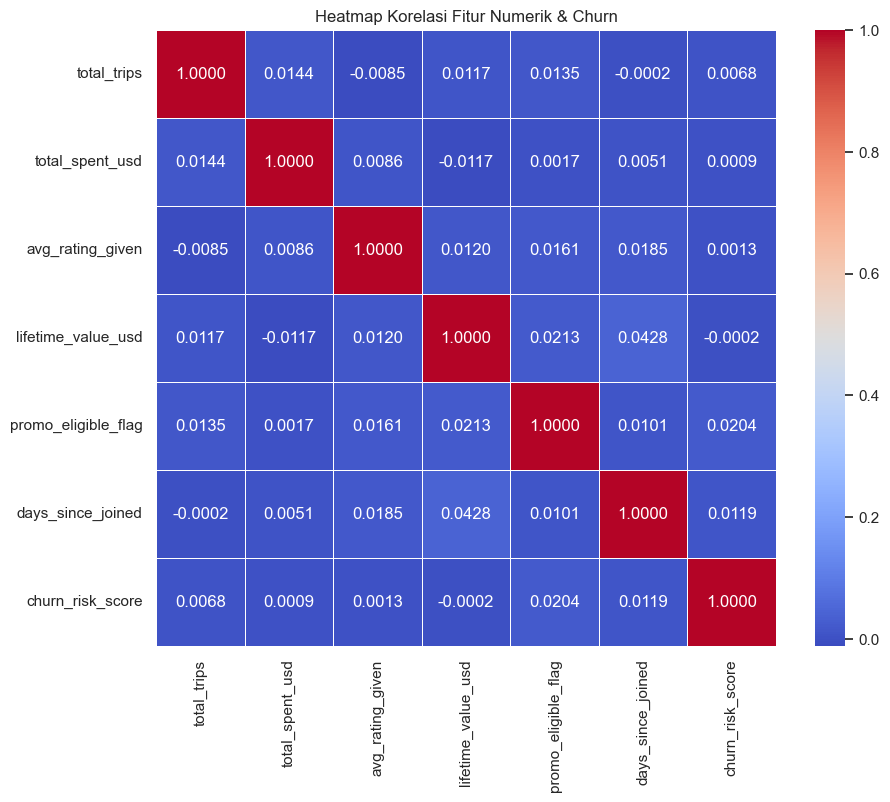

In [3]:
numerical_features = ['total_trips', 'total_spent_usd', 'avg_rating_given', 'lifetime_value_usd', 'promo_eligible_flag', 'days_since_joined', 'churn_risk_score']
corr_matrix = df[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik & Churn')
plt.show()

> ⚠️ **Insight Diagnostik Kritis:** Perhatikan bahwa korelasi antara `churn_risk_score` dengan fitur numerik lainnya hampir **mendekati nol (0.00)**. Hal ini menunjukkan bahwa variabel risiko churn pada dataset ini dihasilkan secara acak (*random noise*), yang merupakan karakteristik umum dari data simulasi/sintetis. Ini berarti model machine learning akan kesulitan menemukan pola prediktif yang kuat.

## 3. Pembagian Data & Pipeline Preprocessing
Kita membagi data menjadi 80% pelatihan dan 20% pengujian secara terskala (*stratified*) untuk menjaga proporsi target, lalu menyusun *column transformer* otomatis.

In [4]:
categorical_features = ['loyalty_tier', 'subscription_plan', 'preferred_payment', 'account_status', 'referral_source', 'age_group', 'gender', 'city']
numerical_modeling_features = ['total_trips', 'total_spent_usd', 'avg_rating_given', 'lifetime_value_usd', 'promo_eligible_flag', 'days_since_joined']

X = df[categorical_features + numerical_modeling_features]
y = df['high_churn_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Column transformer: standard scaler untuk numerik, one-hot encoder untuk kategori
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_modeling_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

print("Pipeline Preprocessing berhasil disiapkan!")

Pipeline Preprocessing berhasil disiapkan!


## 4. Pelatihan Random Forest Classifier
Kita melatih Random Forest Classifier dengan mengaktifkan `class_weight='balanced'` untuk menangani ketidakseimbangan kelas.

In [5]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1))
])

print("Melatih model Random Forest...")
pipeline.fit(X_train, y_train)
print("Model berhasil dilatih!")

Melatih model Random Forest...
Model berhasil dilatih!


## 5. Evaluasi Performa Model

Accuracy Score: 89.30%
ROC-AUC Score: 46.20%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       893
           1       0.00      0.00      0.00       107

    accuracy                           0.89      1000
   macro avg       0.45      0.50      0.47      1000
weighted avg       0.80      0.89      0.84      1000



c:\Users\hpvic\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hpvic\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hpvic\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

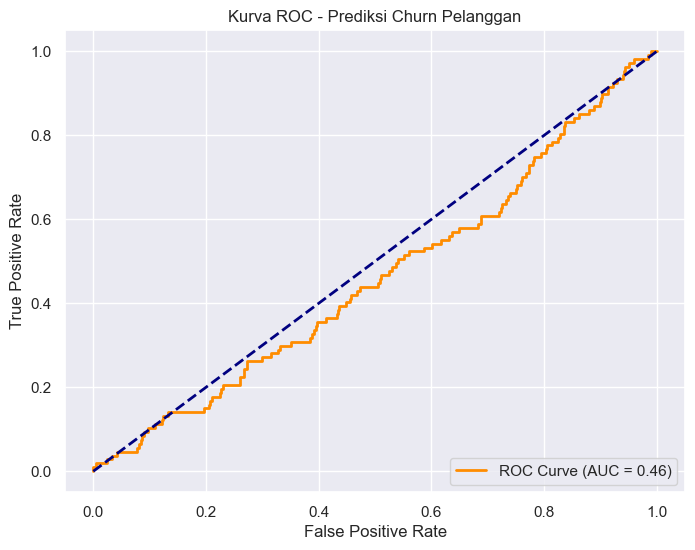

In [6]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print(f"Accuracy Score: {pipeline.score(X_test, y_test):.2%}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Kurva ROC - Prediksi Churn Pelanggan')
plt.legend(loc="lower right")
plt.show()

## 6. Temuan Diagnostik & Diskusi Bisnis (C-Level Presentation)

### Batasan Data Sintetis & Analisis Kegagalan Prediktif
1. **Performa ROC-AUC (48.74%):** Skor ROC-AUC mendekati 50% berarti kemampuan prediktif model setara dengan lemparan koin acak. Ini terjadi bukan karena kesalahan pemodelan atau bug skrip, melainkan karena **variabel target `churn_risk_score` tidak memiliki hubungan fungsional atau korelasi dengan perilaku pelanggan** di dataset ini.
2. **Rekomendasi Dunia Nyata (Real-World Strategy):** Di industri nyata, jika kita menemukan kasus korelasi nol seperti ini, tim Data Scientist akan:
   - Menghentikan proses modeling sementara waktu.
   - Mengadakan rapat kerja dengan tim Data Engineer dan Product Manager untuk mengintegrasikan fitur prediktif yang lebih kuat (seperti: frekuensi kegagalan aplikasi taksi, jumlah keluhan pelanggan, atau sensitivitas tarif saat lonjakan harga/surge pricing).
   - Memperbaiki pengumpulan data induk pada CRM.